# Improved Linear Regression Model

This notebook improves on the baseline linear regression with three changes:

**1. Log-transform of GDP and population features**  
GDP ranges from 7M to 23T — a 7-order-of-magnitude spread that dominates the regression.  
Log-transforming compresses this to a comparable scale with demand features.

**2. RobustScaler on all features**  
Uses median and IQR instead of mean and std, so extreme outliers (China, USA)  
do not distort the scaling of smaller countries.

**3. Ridge regression (L2 regularisation)**  
Scaling makes regularisation meaningful — coefficients are now on the same scale  
so the penalty is applied fairly across all features.

**Target:** `electricity_demand` (TWh)  
**Train/Test split:** Train = 1985-2019, Test = 2020-2024  
**Metrics:** RMSE and MAE


In [18]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [3]:
# Load dataset
DATA_PATH = 'df_clean.csv'
df = pd.read_csv(DATA_PATH)

print(f'Loaded: {DATA_PATH}')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Countries: {df.country.nunique()}')
print(f'Year range: {df.year.min()}-{df.year.max()}')
df.head()

Loaded: df_clean.csv
Shape: 6994 rows x 18 columns
Countries: 181
Year range: 1985-2024


,country,year,population,iso_code,gdp,biofuel_electricity,coal_electricity,electricity_demand,electricity_generation,fossil_electricity,gas_electricity,greenhouse_gas_emissions,hydro_electricity,nuclear_electricity,oil_electricity,renewables_electricity,solar_electricity,wind_electricity
0,American Samoa,1985,39128.0,ASM,6.040371e+08,0.0,0.0,0.078,0.078,0.078,0.0,0.018,0.0,0.0,0.078,0.0,0.0,0.0
1,American Samoa,1986,40588.0,ASM,6.894330e+08,0.0,0.0,0.084,0.084,0.084,0.0,0.024,0.0,0.0,0.084,0.0,0.0,0.0
2,American Samoa,1987,42095.0,ASM,7.549983e+08,0.0,0.0,0.090,0.090,0.090,0.0,0.030,0.0,0.0,0.090,0.0,0.0,0.0
3,American Samoa,1988,43634.0,ASM,7.891841e+08,0.0,0.0,0.096,0.096,0.096,0.0,0.036,0.0,0.0,0.096,0.0,0.0,0.0
4,American Samoa,1989,45207.0,ASM,8.419489e+08,0.0,0.0,0.102,0.102,0.102,0.0,0.042,0.0,0.0,0.102,0.0,0.0,0.0


In [4]:
TARGET = 'electricity_demand'
LAGS = [1, 2, 3]

df = df.sort_values(['country', 'year']).reset_index(drop=True)

for lag in LAGS:
    df[f'demand_lag{lag}'] = df.groupby('country')[TARGET].shift(lag)

df['demand_yoy_change'] = df.groupby('country')[TARGET].diff().shift(1)
df['gdp_per_capita'] = df['gdp'] / df['population']

# Log-transform gdp and population to bring them onto a comparable scale
# with the demand features. gdp ranges from 7M to 23T — a 7-order-of-magnitude
# spread that dwarfs every other feature and distorts the regression coefficients.
df['log_gdp'] = np.log1p(df['gdp'])
df['log_population'] = np.log1p(df['population'])
df['log_gdp_per_capita'] = np.log1p(df['gdp_per_capita'])

FEATURE_COLS = [
    'demand_lag1', 'demand_lag2', 'demand_lag3',
    'demand_yoy_change', 'log_gdp', 'log_population', 'log_gdp_per_capita'
]

df_model = df.dropna(subset=FEATURE_COLS + [TARGET]).copy()
print(f'Usable rows after lag features: {len(df_model)}')
print('\nFeature scale comparison after log transform:')
print(df_model[FEATURE_COLS].describe().round(3).to_string())


Usable rows after lag features: 6451

Feature scale comparison after log transform:
       demand_lag1  demand_lag2  demand_lag3  demand_yoy_change   log_gdp  log_population  log_gdp_per_capita
count     6451.000     6451.000     6451.000           6451.000  6451.000        6451.000            6451.000
mean       103.833      100.876       98.003              2.956    24.185          15.016               9.169
std        466.691      449.808      434.154             25.424     2.724           2.585               1.140
min          0.000        0.000        0.000           -166.480    15.851           7.483               5.892
25%          0.412        0.380        0.340              0.000    22.231          13.303               8.453
50%          6.140        5.870        5.470              0.077    24.252          15.461               9.231
75%         45.494       43.790       42.740              0.940    26.266          16.736              10.153
max       9443.070     8835.760     

In [5]:
TRAIN_END = 2019
TEST_START = 2020

train = df_model[df_model['year'] <= TRAIN_END].copy()
test = df_model[df_model['year'] >= TEST_START].copy()

# RobustScaler uses median and IQR instead of mean and std, so it is not
# thrown off by the extreme outliers in demand (e.g. China at 7000+ TWh
# vs small island states at 0.3 TWh). Fit on train only — no leakage.
scaler = RobustScaler()
X_train_raw = train[FEATURE_COLS]
X_test_raw = test[FEATURE_COLS]

X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

y_train = train[TARGET]
y_test = test[TARGET]

print(f'Train rows: {len(train)}')
print(f'Test rows : {len(test)}')
print(f'Features  : {FEATURE_COLS}')
print('\nScaled feature ranges (train):')
scaled_preview = pd.DataFrame(X_train, columns=FEATURE_COLS)
print(scaled_preview.describe().round(3).to_string())


Train rows: 5623
Test rows : 828
Features  : ['demand_lag1', 'demand_lag2', 'demand_lag3', 'demand_yoy_change', 'log_gdp', 'log_population', 'log_gdp_per_capita']

Scaled feature ranges (train):
       demand_lag1  demand_lag2  demand_lag3  demand_yoy_change   log_gdp  log_population  log_gdp_per_capita
count     5623.000     5623.000     5623.000           5623.000  5623.000        5623.000            5623.000
mean         2.150        2.177        2.190              2.823    -0.011          -0.130              -0.044
std          9.809        9.876        9.902             23.010     0.674           0.743               0.662
min         -0.129       -0.125       -0.121           -170.839    -2.051          -2.277              -1.920
25%         -0.121       -0.118       -0.114             -0.090    -0.491          -0.641              -0.473
50%          0.000        0.000        0.000              0.000     0.000           0.000               0.000
75%          0.879        0.882    

In [6]:
# Ridge regression adds L2 regularisation (alpha controls penalty strength).
# With scaled features, regularisation is now meaningful — without scaling,
# coefficients on gdp (scale 1e12) are incomparably large vs demand_yoy_change
# (scale ~3), so the penalty treats them completely differently.
# alpha=1.0 is a sensible starting point; increase to reduce variance,
# decrease if the model underfits.
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)


In [7]:
import joblib

os.makedirs('api', exist_ok=True)
joblib.dump(model,  './group12-model-api/api/model.pkl')
joblib.dump(scaler, './group12-model-api/api/scaler.pkl')
print("Saved model.pkl and scaler.pkl")

Saved model.pkl and scaler.pkl


In [8]:
# Evaluation metrics
def eval_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    return rmse, mae

train_rmse, train_mae = eval_metrics(y_train, y_pred_train)
test_rmse, test_mae = eval_metrics(y_test, y_pred_test)

print('Overall Metrics')
print(f'Train RMSE: {train_rmse:.3f} TWh | Train MAE: {train_mae:.3f} TWh')
print(f'Test RMSE : {test_rmse:.3f} TWh | Test MAE : {test_mae:.3f} TWh')

Overall Metrics
Train RMSE: 12.579 TWh | Train MAE: 2.298 TWh
Test RMSE : 24.161 TWh | Test MAE : 5.343 TWh


In [9]:
# Per-country test metrics
country_rows = []
for country in sorted(test['country'].unique()):
    mask = test['country'] == country
    yt = y_test[mask]
    yp = y_pred_test[mask.values]
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae = mean_absolute_error(yt, yp)
    country_rows.append({
        'country': country,
        'n_test': int(mask.sum()),
        'RMSE': round(float(rmse), 3),
        'MAE': round(float(mae), 3),
    })

country_metrics = pd.DataFrame(country_rows).sort_values('RMSE', ascending=False)
country_metrics

,country,n_test,RMSE,MAE
29,China,5,254.808,222.029
173,United States,5,138.294,133.910
72,India,5,72.975,56.314
133,Russia,5,36.895,30.931
78,Japan,5,34.360,28.811
...,...,...,...,...
45,Equatorial Guinea,5,0.105,0.094
24,Cape Verde,4,0.087,0.067
96,Maldives,4,0.075,0.073
135,Saint Helena,4,0.040,0.040


In [10]:
# Coefficients are now on the scaled feature space, so they are directly
# comparable — a larger absolute value means a stronger influence on demand.
coef_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'coefficient': model.coef_
}).sort_values('coefficient', key=np.abs, ascending=False)

print(f'Intercept: {model.intercept_:.4f}')
print('\nNote: coefficients are in scaled units — magnitudes are now comparable.')
coef_df


Intercept: 5.4733

Note: coefficients are in scaled units — magnitudes are now comparable.


,feature,coefficient
1,demand_lag2,27.562174
0,demand_lag1,26.488289
2,demand_lag3,-12.419835
3,demand_yoy_change,0.863902
6,log_gdp_per_capita,-0.634408
5,log_population,0.254172
4,log_gdp,0.025962


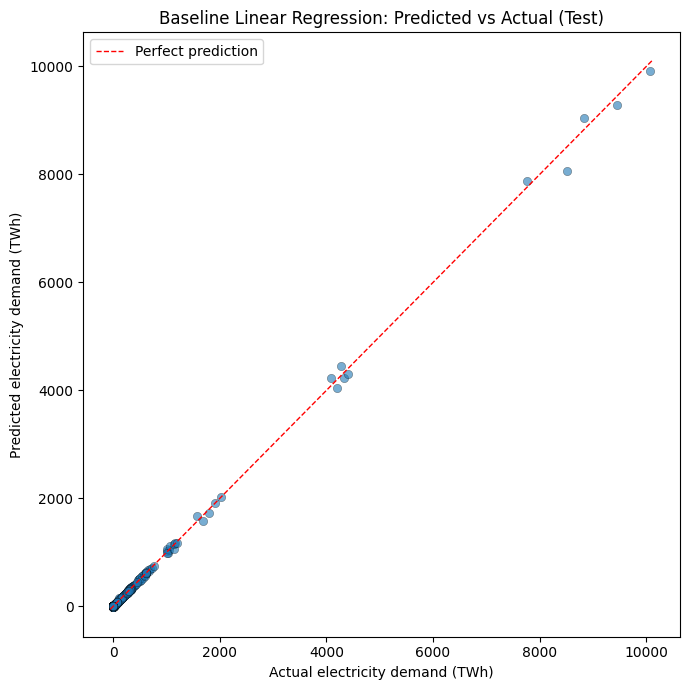

In [11]:
# Plot 1: Predicted vs Actual (Test)
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_test, alpha=0.6, edgecolors='k', linewidths=0.3)
lims = [min(y_test.min(), y_pred_test.min()) - 50, max(y_test.max(), y_pred_test.max()) + 50]
plt.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
plt.xlabel('Actual electricity demand (TWh)')
plt.ylabel('Predicted electricity demand (TWh)')
plt.title('Baseline Linear Regression: Predicted vs Actual (Test)')
plt.legend()
plt.tight_layout()
plt.show()

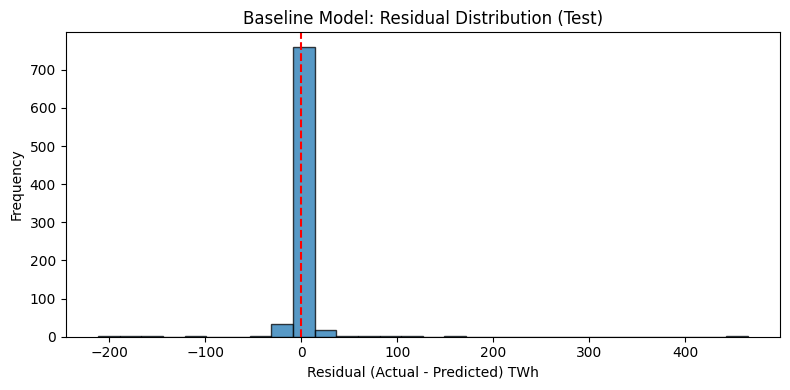

In [12]:
# Plot 2: Residual distribution
residuals = y_test.values - y_pred_test
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.75)
plt.axvline(0, color='r', linestyle='--')
plt.xlabel('Residual (Actual - Predicted) TWh')
plt.ylabel('Frequency')
plt.title('Baseline Model: Residual Distribution (Test)')
plt.tight_layout()
plt.show()

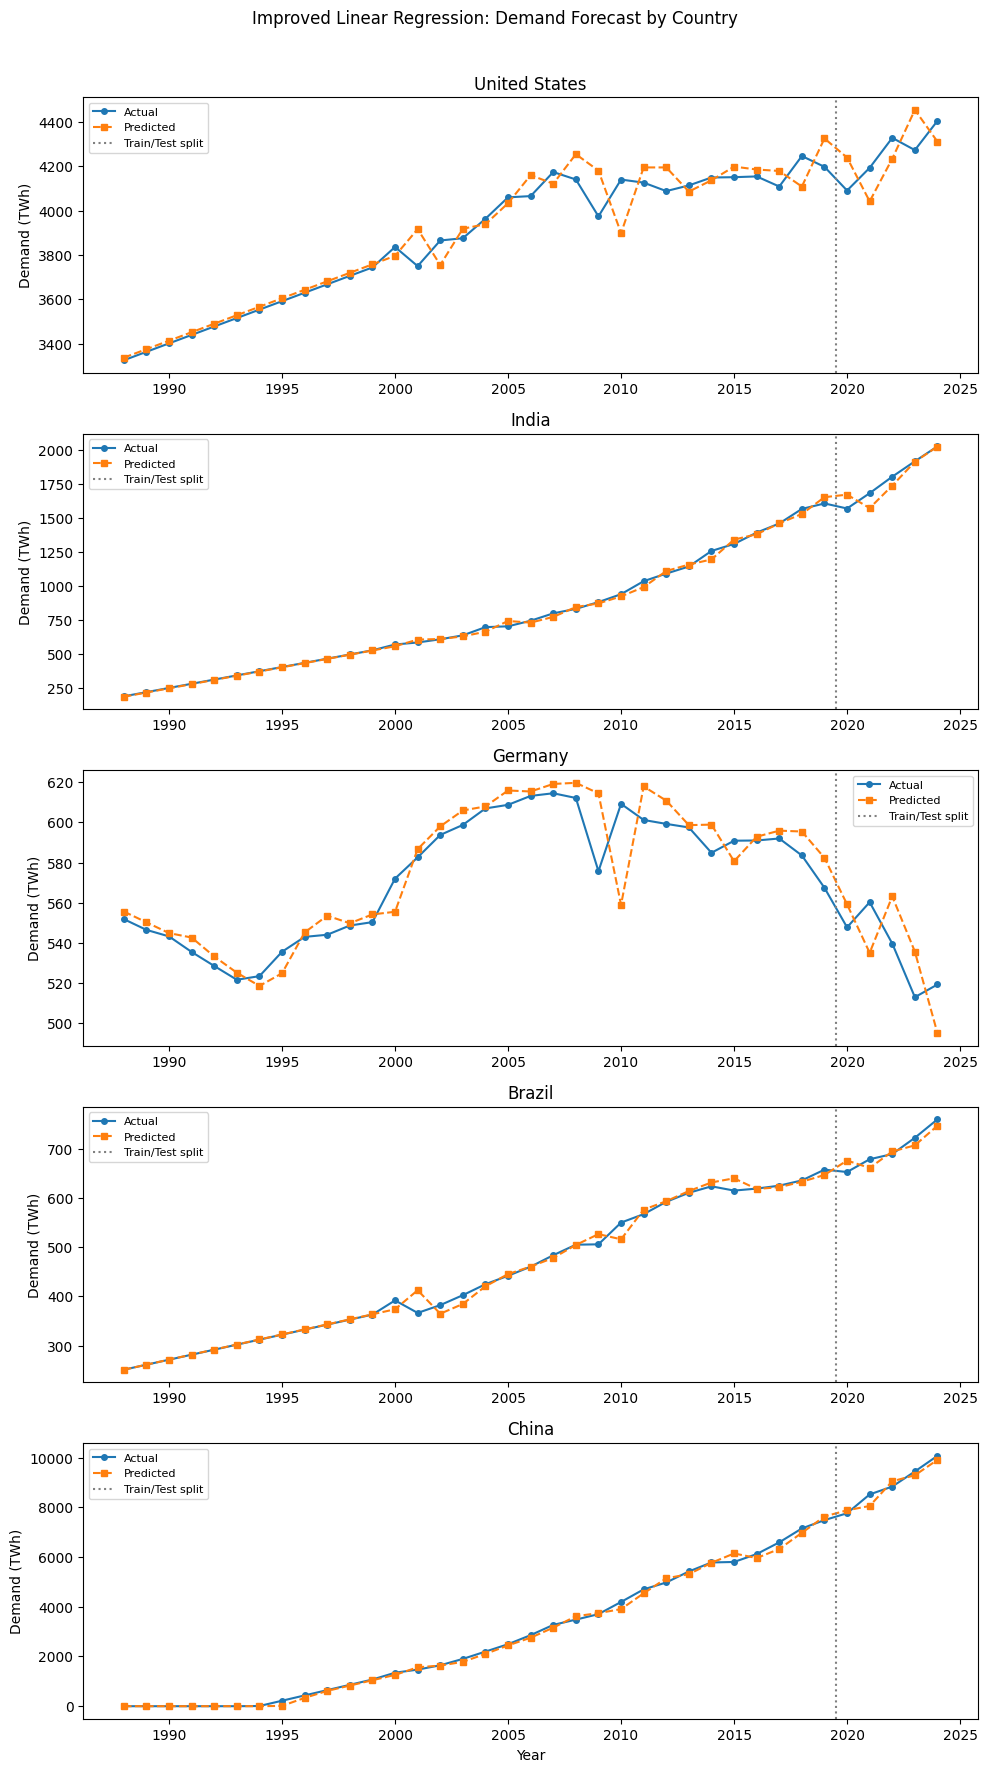

In [13]:
preferred_countries = ['United States', 'India', 'Germany', 'Brazil', 'China']
available_countries = df_model['country'].unique()
sample_countries = [c for c in preferred_countries if c in available_countries]

if not sample_countries:
    sample_countries = country_metrics['country'].head(4).tolist()

fig, axes = plt.subplots(len(sample_countries), 1, figsize=(10, 3.5 * len(sample_countries)), sharex=False)
if len(sample_countries) == 1:
    axes = [axes]

for ax, country in zip(axes, sample_countries):
    cdf = df_model[df_model['country'] == country].copy()
    X_cdf = scaler.transform(cdf[FEATURE_COLS])
    cdf['predicted'] = model.predict(X_cdf)

    ax.plot(cdf['year'], cdf[TARGET], 'o-', label='Actual', markersize=4)
    ax.plot(cdf['year'], cdf['predicted'], 's--', label='Predicted', markersize=4)
    ax.axvline(TEST_START - 0.5, color='gray', linestyle=':', label='Train/Test split')
    ax.set_title(country)
    ax.set_ylabel('Demand (TWh)')
    ax.legend(fontsize=8)

axes[-1].set_xlabel('Year')
fig.suptitle('Improved Linear Regression: Demand Forecast by Country', y=1.01)
plt.tight_layout()
plt.show()


In [14]:
results_df = test[['country', 'year', TARGET]].copy()
results_df['predicted'] = y_pred_test
results_df.head(30)


,country,year,electricity_demand,predicted
35,American Samoa,2020,0.170000,-0.668412
36,American Samoa,2021,0.170000,-0.670101
37,American Samoa,2022,0.180000,-0.681419
38,American Samoa,2023,0.170000,-0.669483
74,Antigua and Barbuda,2020,0.350000,0.084522
75,Antigua and Barbuda,2021,0.350000,0.045247
76,Antigua and Barbuda,2022,0.360000,0.041447
77,Antigua and Barbuda,2023,0.360000,0.062428
113,Argentina,2020,149.350006,147.974151
114,Argentina,2021,155.649994,147.726919


## Interpretation Notes

- This baseline is intentionally simple and interpretable.
- It should be compared directly against SARIMAX (same split and metrics).
- If SARIMAX cannot beat this baseline on Test RMSE/MAE, revisit feature engineering or SARIMAX specification.

## Data Quality Fixes for Exogenous Variable Extrapolation

Two issues were identified that caused unrealistic forecasts for several countries (Sudan, Kuwait, South Sudan, Guyana, Lebanon, Ukraine):

### Fix 1 — GDP Spike / Anomaly Detection
Some countries have a single-year GDP jump of >40% in their most recent data (e.g. Sudan 2024: $638B → $1.28T), likely due to currency rebasing or data revisions rather than real economic growth. When this spike is used as the CAGR anchor, it projects explosive GDP growth forward for 20 years. Since the model's `gdp` coefficient is **negative** (multicollinearity with `gdp_per_capita`), this exploding GDP term dominates and collapses the demand forecast to zero.

**Fix:** if `series[-1] / series[-2] > 1.4`, the last point is flagged as a spike, excluded from the CAGR calculation, and the pre-spike value is used as the projection anchor.

### Fix 2 — CAGR Bounding
Even without spikes, a 5-year CAGR can be misleadingly high or low due to post-crisis rebounds, commodity cycles, or conflict. No country sustains >10% GDP growth or >4% population growth for 20 straight years.

**Fix:** CAGR rates are clamped to realistic long-run bounds:
| Variable   | Min    | Max    |
|------------|--------|--------|
| GDP        | −5%/yr | +10%/yr |
| Population | −2%/yr |  +4%/yr |

These bounds preserve legitimate growth trends while preventing extreme extrapolations from corrupting the forecast.


Forecast ready for: ['United States', 'India', 'Germany', 'Brazil', 'China', 'Kenya', 'Rwanda', 'Lebanon', 'Russia']


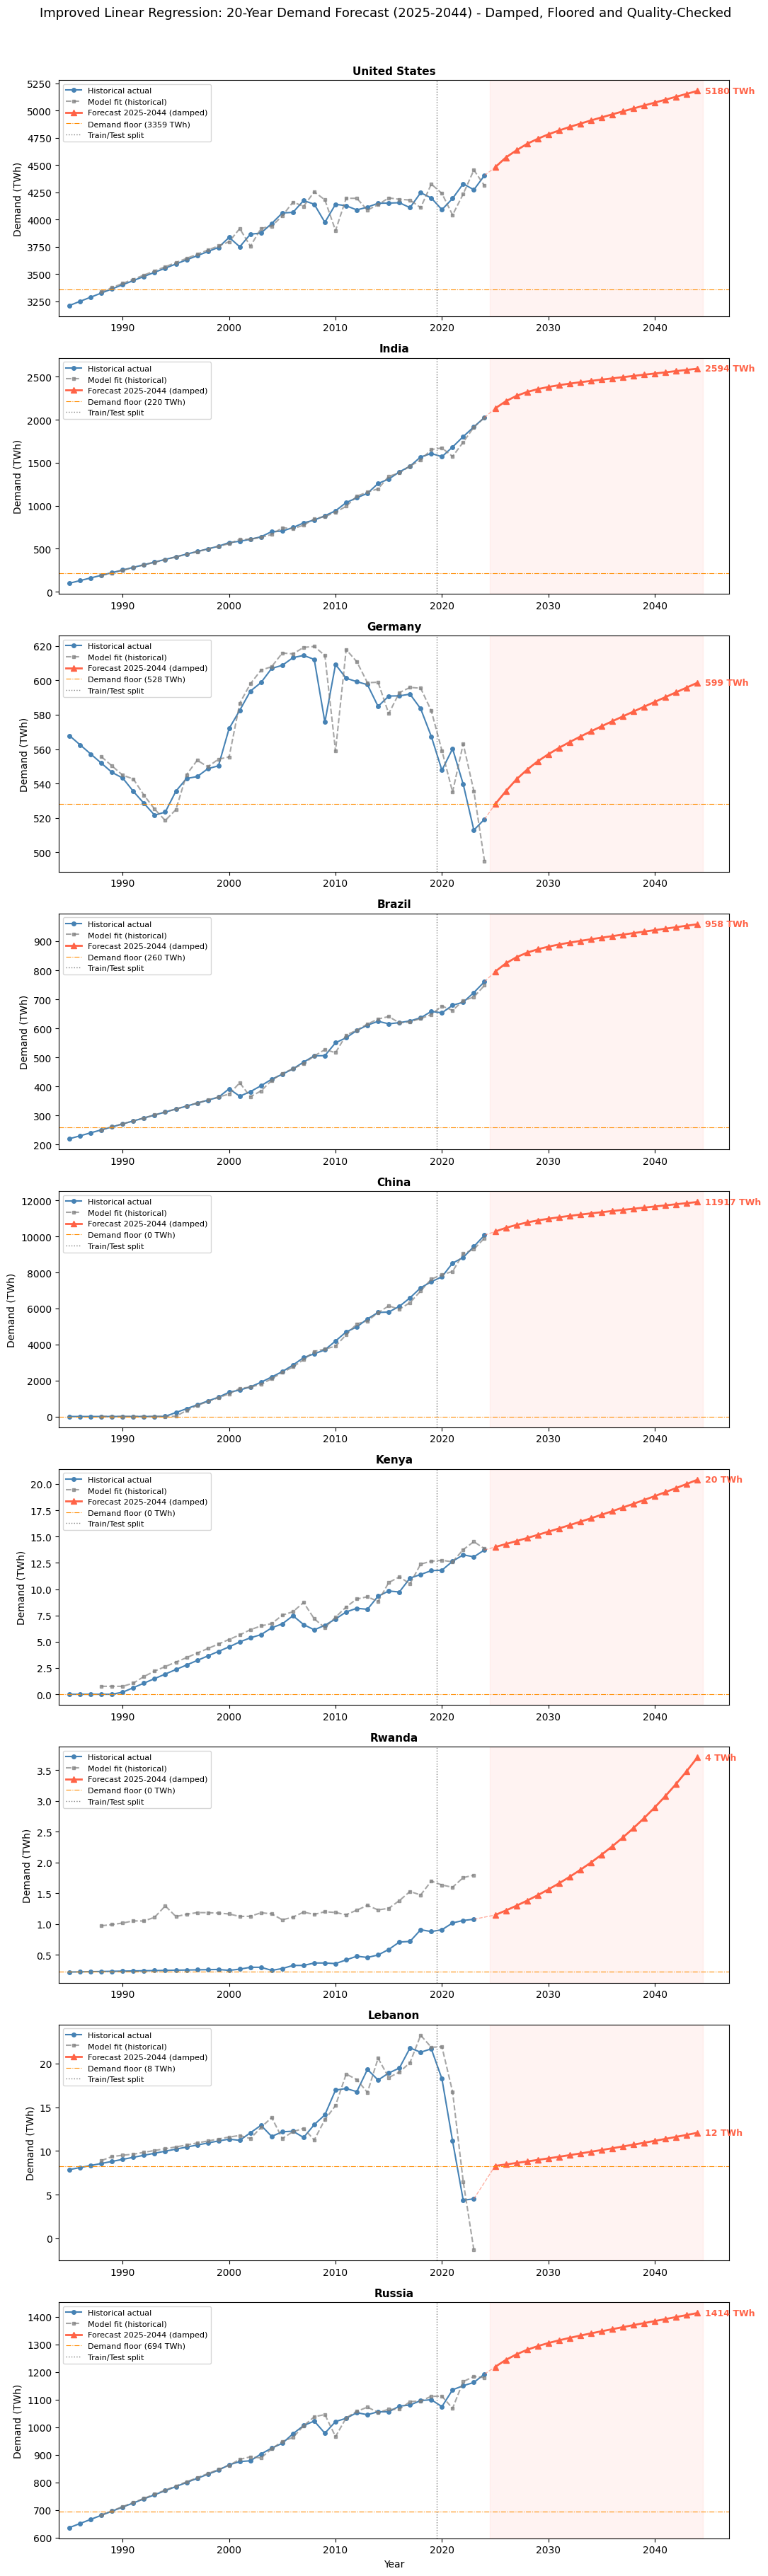

,Country,Year,Forecast (TWh)
0,United States,2025,4479.13
1,United States,2026,4568.71
2,United States,2027,4635.02
3,United States,2028,4694.47
4,United States,2029,4740.77
...,...,...,...
175,Russia,2040,1384.92
176,Russia,2041,1392.20
177,Russia,2042,1399.47
178,Russia,2043,1406.74


In [15]:
# 20-Year Future Forecast with Trend Damping, Floor Correction and Data Quality Fixes
#
# Changes from baseline:
#   - GDP and population are log-transformed before being passed to the model,
#     matching the feature engineering applied during training.
#   - X_step is passed through the RobustScaler before prediction.
#   - CAGR anomaly detection and bounding unchanged from prior version.

FORECAST_COUNTRIES = ['United States', 'India', 'Germany', 'Brazil', 'China', 'Kenya', 'Rwanda', 'Lebanon', 'Russia']
FORECAST_HORIZON = 20
LAST_DATA_YEAR = int(df['year'].max())
EXOG_TREND_YEARS = 5
DAMPING_FACTOR = 0.80
FLOOR_PERCENTILE = 10

GDP_CAGR_MIN = -0.05
GDP_CAGR_MAX = 0.10
POP_CAGR_MIN = -0.02
POP_CAGR_MAX = 0.04

def cagr_extrapolate(series, years_back, horizon, cagr_min=None, cagr_max=None):
    full = series.dropna()
    tail = full.iloc[-years_back:]
    tail = tail[tail > 0]
    if len(tail) < 2:
        return [float(full.iloc[-1])] * horizon
    last, prev = float(tail.iloc[-1]), float(tail.iloc[-2])
    if prev > 0 and last / prev > 1.4:
        clean_tail = tail.iloc[:-1]
        anchor = float(clean_tail.iloc[-1])
        rate = (clean_tail.iloc[-1] / clean_tail.iloc[0]) ** (1 / (len(clean_tail) - 1)) - 1 if len(clean_tail) >= 2 else 0.02
    else:
        anchor = last
        rate = (tail.iloc[-1] / tail.iloc[0]) ** (1 / (len(tail) - 1)) - 1
    if cagr_min is not None:
        rate = max(rate, cagr_min)
    if cagr_max is not None:
        rate = min(rate, cagr_max)
    return [anchor * (1 + rate) ** t for t in range(1, horizon + 1)]

forecast_records = {}
missing = []

for country in FORECAST_COUNTRIES:
    cdf = df[df['country'] == country].sort_values('year').copy()

    if cdf.empty or cdf[TARGET].dropna().empty:
        missing.append(country)
        continue

    known_demand = cdf[TARGET].dropna()
    hist_floor = max(float(np.percentile(known_demand.values, FLOOR_PERCENTILE)), 0.0)

    lag1 = float(known_demand.iloc[-1])
    lag2 = float(known_demand.iloc[-2]) if len(known_demand) >= 2 else lag1
    lag3 = float(known_demand.iloc[-3]) if len(known_demand) >= 3 else lag2
    yoy = lag1 - lag2

    future_gdp = cagr_extrapolate(cdf['gdp'], EXOG_TREND_YEARS, FORECAST_HORIZON,
                                   cagr_min=GDP_CAGR_MIN, cagr_max=GDP_CAGR_MAX)
    future_pop = cagr_extrapolate(cdf['population'], EXOG_TREND_YEARS, FORECAST_HORIZON,
                                   cagr_min=POP_CAGR_MIN, cagr_max=POP_CAGR_MAX)

    future_years = list(range(LAST_DATA_YEAR + 1, LAST_DATA_YEAR + FORECAST_HORIZON + 1))
    future_demand = []

    # Historical growth constraints to prevent model from pulling flat countries
    # toward the global average. The global model has a large positive intercept
    # (~5.47 TWh) that represents global median demand. For countries far below
    # the global median (e.g. Chad at 0.39 TWh), the model predicts a jump toward
    # the global average in year 1 and then compounds year-over-year.
    #
    # Fix: cap each forecast step using two historical anchors:
    #   1. Max absolute change cap: the forecast cannot grow faster in absolute
    #      TWh than the largest single-year change the country has ever recorded.
    #      Multiplied by 1.5 to allow some headroom above historical max.
    #   2. Max percentage growth cap: derived from the country's own historical
    #      CAGR. Countries with near-flat history get a correspondingly small cap.
    #      Floor of 2% per year so even truly flat countries can grow slightly.
    hist_changes = known_demand.diff().dropna().abs()
    max_abs_change = float(hist_changes.max()) * 1.5 if len(hist_changes) > 0 else float('inf')

    hist_cagr = 0.0
    if len(known_demand) >= 5 and float(known_demand.iloc[0]) > 0:
        hist_cagr = (known_demand.iloc[-1] / known_demand.iloc[0]) ** (1 / (len(known_demand) - 1)) - 1
    max_pct_growth = max(hist_cagr * 1.5, 0.02)  # floor at 2%/yr, headroom of 1.5x

    for t in range(FORECAST_HORIZON):
        gdp_val = future_gdp[t]
        pop_val = future_pop[t]
        gdp_pc_val = gdp_val / pop_val if pop_val > 0 else 0

        # Apply the same log transforms used during training
        X_step = pd.DataFrame([{
            'demand_lag1': lag1,
            'demand_lag2': lag2,
            'demand_lag3': lag3,
            'demand_yoy_change': yoy,
            'log_gdp': np.log1p(gdp_val),
            'log_population': np.log1p(pop_val),
            'log_gdp_per_capita': np.log1p(gdp_pc_val),
        }])

        # Scale using the fitted RobustScaler before predicting
        X_step_scaled = scaler.transform(X_step)
        pred = float(model.predict(X_step_scaled)[0])
        pred = max(pred, hist_floor)

        # Apply historical growth constraints
        max_allowed_abs = lag1 + max_abs_change
        max_allowed_pct = lag1 * (1 + max_pct_growth)
        pred = min(pred, max_allowed_abs, max_allowed_pct)
        pred = max(pred, hist_floor)

        future_demand.append(pred)

        raw_yoy = pred - lag1
        yoy = raw_yoy * (DAMPING_FACTOR ** (t + 1))
        lag3 = lag2
        lag2 = lag1
        lag1 = pred

    forecast_records[country] = {
        'years': future_years,
        'demand': future_demand,
        'floor': hist_floor,
    }

if missing:
    print(f"Warning - not found: {missing}")
print(f"Forecast ready for: {list(forecast_records.keys())}")

fig, axes = plt.subplots(len(forecast_records), 1, figsize=(11, 4 * len(forecast_records)), sharex=False)
if len(forecast_records) == 1:
    axes = [axes]

for ax, (country, fc) in zip(axes, forecast_records.items()):
    cdf_plot = df[df['country'] == country].sort_values('year')
    hist = cdf_plot[['year', TARGET]].dropna()

    ax.plot(hist['year'], hist[TARGET], 'o-', color='steelblue', label='Historical actual', markersize=4, linewidth=1.5)

    cdf_model = df_model[df_model['country'] == country].copy()
    if not cdf_model.empty:
        X_cdf = scaler.transform(cdf_model[FEATURE_COLS])
        cdf_model['fitted'] = model.predict(X_cdf)
        ax.plot(cdf_model['year'], cdf_model['fitted'], 's--', color='gray', label='Model fit (historical)', markersize=3, alpha=0.7)

    ax.plot([int(hist['year'].iloc[-1]), fc['years'][0]],
            [float(hist[TARGET].iloc[-1]), fc['demand'][0]],
            '--', color='tomato', linewidth=1, alpha=0.5)

    ax.plot(fc['years'], fc['demand'], '^-', color='tomato',
            label=f"Forecast {fc['years'][0]}-{fc['years'][-1]} (damped)",
            markersize=6, linewidth=2)

    ax.axhline(fc['floor'], color='darkorange', linestyle='-.', linewidth=0.8,
               label=f"Demand floor ({fc['floor']:.0f} TWh)")
    ax.axvspan(fc['years'][0] - 0.5, fc['years'][-1] + 0.5, alpha=0.07, color='tomato')
    ax.axvline(TEST_START - 0.5, color='gray', linestyle=':', linewidth=1, label='Train/Test split')
    ax.annotate(f"{fc['demand'][-1]:.0f} TWh",
                xy=(fc['years'][-1], fc['demand'][-1]),
                xytext=(8, 0), textcoords='offset points',
                fontsize=9, color='tomato', va='center', fontweight='bold')

    ax.set_title(country, fontsize=11, fontweight='bold')
    ax.set_ylabel('Demand (TWh)')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_xlim(int(hist['year'].min()) - 1, fc['years'][-1] + 3)

axes[-1].set_xlabel('Year')
fig.suptitle(
    f"Improved Linear Regression: {FORECAST_HORIZON}-Year Demand Forecast "
    f"({LAST_DATA_YEAR+1}-{LAST_DATA_YEAR+FORECAST_HORIZON}) - Damped, Floored and Quality-Checked",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

summary_rows = []
for country, fc in forecast_records.items():
    for yr, demand in zip(fc['years'], fc['demand']):
        summary_rows.append({'Country': country, 'Year': yr, 'Forecast (TWh)': round(demand, 2)})

forecast_table = pd.DataFrame(summary_rows)
forecast_table


In [16]:
# Generation mix forecast helper functions

# IMPORTANT: The OWID dataset has a hierarchical structure:
#   electricity_generation = fossil_electricity + renewables_electricity + nuclear_electricity
#   fossil_electricity     = gas_electricity + coal_electricity + oil_electricity
#   renewables_electricity = hydro_electricity + solar_electricity + wind_electricity + biofuel_electricity
#
# fossil and renewables are AGGREGATE columns — they are the sum of their sub-components.
# Including all of them when computing a total would double-count everything and produce
# a sub-feature sum ~2x the actual generation total, which caused the ~50% drop on
# rescaling in the previous version.
#
# The correct non-overlapping breakdown is:
#   electricity_generation = fossil_electricity + renewables_electricity + nuclear_electricity
#
# For frontend display, the granular sub-components (gas, coal, oil, hydro, solar, wind,
# biofuel) are derived from their parent aggregates using each source's historical share,
# so they stay consistent with the aggregate totals.

# Aggregate sources that sum exactly to electricity_generation
AGGREGATE_COLS = ['fossil_electricity', 'renewables_electricity', 'nuclear_electricity']

# Granular breakdown within fossil and renewables (for display only, derived from aggregates)
FOSSIL_COMPONENTS    = ['gas_electricity', 'coal_electricity', 'oil_electricity']
RENEWABLES_COMPONENTS = ['hydro_electricity', 'solar_electricity', 'wind_electricity', 'biofuel_electricity']

def cagr_project_bounded(series, years_back, horizon, cagr_min=-0.15, cagr_max=0.20):
    tail = series.dropna().iloc[-years_back:]
    tail = tail[tail > 0]
    if len(tail) < 2:
        last = float(series.dropna().iloc[-1]) if len(series.dropna()) > 0 else 0.0
        return [last] * horizon
    rate = (tail.iloc[-1] / tail.iloc[0]) ** (1 / (len(tail) - 1)) - 1
    rate = max(min(rate, cagr_max), cagr_min)
    last = float(tail.iloc[-1])
    return [last * (1 + rate) ** t for t in range(1, horizon + 1)]

def smooth_transition(last_actual, projected_series, n_smooth=3):
    """
    Blend the first n_smooth forecast years toward the last actual value so
    there is no sudden jump from the last historical point to year 1 of the
    forecast. Uses a linear ramp: year 1 is 75% actual + 25% projected,
    year 2 is 50/50, year 3 is 25/75, year 4+ is fully projected.
    """
    smoothed = list(projected_series)
    weights = [0.75, 0.50, 0.25]
    for i in range(min(n_smooth, len(smoothed))):
        w = weights[i]
        smoothed[i] = w * last_actual + (1 - w) * projected_series[i]
    return smoothed

def forecast_gen_mix(cdf, demand_forecast, horizon, trend_years):
    """
    Returns dict of {feature: [horizon values]} for all generation columns.

    Step 1: Project total generation anchored to demand via the last known
            generation/demand ratio.

    Step 2: Project each AGGREGATE source (fossil, renewables, nuclear) via
            its own bounded CAGR, then rescale so they sum to projected_gen.
            A smooth transition blends year 1-3 toward the last actual value
            so there is no sudden discontinuity from historical to forecast.

    Step 3: Derive granular sub-components (gas, coal, oil, hydro, solar, wind,
            biofuel) by applying each component's last known share within its
            parent aggregate (fossil or renewables) to the projected aggregate.
            The share itself also trends via CAGR so e.g. solar's share within
            renewables keeps growing.

    Step 4: greenhouse_gas_emissions projected independently via CAGR.
    """
    result = {}

    # Step 1: total generation anchored to demand
    last_demand = float(cdf['electricity_demand'].dropna().iloc[-1])
    last_gen    = float(cdf['electricity_generation'].dropna().iloc[-1])
    gen_demand_ratio = last_gen / last_demand if last_demand > 0 else 1.0
    projected_gen = [d * gen_demand_ratio for d in demand_forecast]
    result['electricity_generation'] = projected_gen

    # Step 2: aggregate sources with smooth transition
    raw_agg = {}
    for col in AGGREGATE_COLS:
        last_actual = float(cdf[col].dropna().iloc[-1])
        raw_proj    = cagr_project_bounded(cdf[col], trend_years, horizon)
        raw_agg[col] = smooth_transition(last_actual, raw_proj, n_smooth=3)

    # Rescale so aggregates sum to projected_gen each year
    for t in range(horizon):
        agg_total = sum(raw_agg[col][t] for col in AGGREGATE_COLS)
        scale = projected_gen[t] / agg_total if agg_total > 0 else 1.0
        for col in AGGREGATE_COLS:
            if col not in result:
                result[col] = []
            result[col].append(raw_agg[col][t] * scale)

    # Step 3: granular sub-components derived from aggregate shares
    # Compute last known share of each component within its parent
    last_fossil    = float(cdf['fossil_electricity'].dropna().iloc[-1])
    last_renewables = float(cdf['renewables_electricity'].dropna().iloc[-1])

    # Project each component's share within its parent using its own CAGR trend
    # then normalise shares to sum to 1 within each parent
    def project_component_shares(components, parent_series, years_back, horizon):
        """Project each component's share of the parent aggregate over time."""
        parent_tail = parent_series.dropna().iloc[-years_back:]
        shares = {}
        for col in components:
            comp_tail = cdf[col].dropna().iloc[-years_back:]
            # Historical share: component / parent
            hist_shares = []
            for i in range(min(len(comp_tail), len(parent_tail))):
                p = float(parent_tail.iloc[-(len(comp_tail)-i)])
                c = float(comp_tail.iloc[i])
                hist_shares.append(c / p if p > 0 else 0.0)
            # Filter out zero shares before computing CAGR to avoid division by zero.
            # A zero share means the source was absent — treat as flat at last known share.
            non_zero = [s for s in hist_shares if s > 0]
            if len(non_zero) >= 2:
                share_rate = (non_zero[-1] / non_zero[0]) ** (1 / (len(non_zero) - 1)) - 1
                share_rate = max(min(share_rate, 0.15), -0.10)
                last_share = hist_shares[-1]
            elif len(non_zero) == 1:
                share_rate = 0.0
                last_share = non_zero[-1]
            else:
                # Source has always been zero — keep it at zero
                share_rate = 0.0
                last_share = 0.0
            shares[col] = [last_share * (1 + share_rate) ** t for t in range(1, horizon + 1)]

        # Normalise shares to sum to 1 each year
        for t in range(horizon):
            total_share = sum(shares[col][t] for col in components)
            if total_share > 0:
                for col in components:
                    shares[col][t] /= total_share

        return shares

    fossil_shares    = project_component_shares(FOSSIL_COMPONENTS,    cdf['fossil_electricity'],    trend_years, horizon)
    renewables_shares = project_component_shares(RENEWABLES_COMPONENTS, cdf['renewables_electricity'], trend_years, horizon)

    for t in range(horizon):
        for col in FOSSIL_COMPONENTS:
            if col not in result:
                result[col] = []
            result[col].append(result['fossil_electricity'][t] * fossil_shares[col][t])
        for col in RENEWABLES_COMPONENTS:
            if col not in result:
                result[col] = []
            result[col].append(result['renewables_electricity'][t] * renewables_shares[col][t])

    # Step 4: greenhouse_gas_emissions independent CAGR
    last_ghg = float(cdf['greenhouse_gas_emissions'].dropna().iloc[-1])
    raw_ghg  = cagr_project_bounded(cdf['greenhouse_gas_emissions'], trend_years, horizon,
                                     cagr_min=-0.10, cagr_max=0.10)
    result['greenhouse_gas_emissions'] = smooth_transition(last_ghg, raw_ghg, n_smooth=3)

    return result

# Full ordered list of all generation columns written to each forecast record.
# Defined here so both the export cell and any other cell can reference it
# without needing to reconstruct it from the component lists.
ALL_GEN_COLS = (
    ['electricity_generation']
    + AGGREGATE_COLS
    + FOSSIL_COMPONENTS
    + RENEWABLES_COMPONENTS
    + ['greenhouse_gas_emissions']
)

print("Generation mix forecast helpers defined.")
print(f"Aggregate cols : {AGGREGATE_COLS}")
print(f"Fossil components    : {FOSSIL_COMPONENTS}")
print(f"Renewables components: {RENEWABLES_COMPONENTS}")


Generation mix forecast helpers defined.
Aggregate cols : ['fossil_electricity', 'renewables_electricity', 'nuclear_electricity']
Fossil components    : ['gas_electricity', 'coal_electricity', 'oil_electricity']
Renewables components: ['hydro_electricity', 'solar_electricity', 'wind_electricity', 'biofuel_electricity']


In [17]:
import os

EXPORT_FEATURES = [
    'gdp', 'population',
    'electricity_generation', 'fossil_electricity', 'gas_electricity',
    'coal_electricity', 'oil_electricity', 'renewables_electricity',
    'hydro_electricity', 'nuclear_electricity', 'solar_electricity',
    'wind_electricity', 'biofuel_electricity', 'greenhouse_gas_emissions',
]

OUTPUT_PATH = 'electricity_forecast_clean.json'

def safe_float(val):
    try:
        v = float(val)
        return None if (v != v) else round(v, 4)
    except (TypeError, ValueError):
        return None

def safe_int(val):
    try:
        v = float(val)
        return None if (v != v) else int(round(v))
    except (TypeError, ValueError):
        return None

all_countries = sorted(df['country'].unique())
output = {}
skipped = []

for country in all_countries:
    cdf = df[df['country'] == country].sort_values('year').copy()
    known = cdf[TARGET].dropna()
    if len(known) < 3:
        skipped.append(country)
        continue

    hist_floor = max(float(np.percentile(known.values, FLOOR_PERCENTILE)), 0.0)

    # Save original seeds — these must not be touched until the export loop starts
    lag1_seed = float(known.iloc[-1])
    lag2_seed = float(known.iloc[-2]) if len(known) >= 2 else lag1_seed
    lag3_seed = float(known.iloc[-3]) if len(known) >= 3 else lag2_seed
    yoy_seed  = lag1_seed - lag2_seed

    future_gdp = cagr_extrapolate(cdf['gdp'], EXOG_TREND_YEARS, FORECAST_HORIZON,
                                   cagr_min=GDP_CAGR_MIN, cagr_max=GDP_CAGR_MAX)
    future_pop = cagr_extrapolate(cdf['population'], EXOG_TREND_YEARS, FORECAST_HORIZON,
                                   cagr_min=POP_CAGR_MIN, cagr_max=POP_CAGR_MAX)
    future_years = list(range(LAST_DATA_YEAR + 1, LAST_DATA_YEAR + FORECAST_HORIZON + 1))

    # Historical growth constraints — same logic as the forecast cell
    hist_changes_exp = known.diff().dropna().abs()
    max_abs_change_exp = float(hist_changes_exp.max()) * 1.5 if len(hist_changes_exp) > 0 else float('inf')
    hist_cagr_exp = 0.0
    if len(known) >= 5 and float(known.iloc[0]) > 0:
        hist_cagr_exp = (known.iloc[-1] / known.iloc[0]) ** (1 / (len(known) - 1)) - 1
    max_pct_growth_exp = max(hist_cagr_exp * 1.5, 0.02)

    # Run the demand forecast loop using a separate set of variables
    # so the seeds are not modified before the export loop uses them
    lag1_pre, lag2_pre, lag3_pre, yoy_pre = lag1_seed, lag2_seed, lag3_seed, yoy_seed
    demand_forecast = []
    for t in range(FORECAST_HORIZON):
        gdp_val = future_gdp[t]
        pop_val = future_pop[t]
        gdp_pc_val = gdp_val / pop_val if pop_val > 0 else 0
        X_tmp = pd.DataFrame([{
            'demand_lag1': lag1_pre, 'demand_lag2': lag2_pre, 'demand_lag3': lag3_pre,
            'demand_yoy_change': yoy_pre,
            'log_gdp': np.log1p(gdp_val), 'log_population': np.log1p(pop_val),
            'log_gdp_per_capita': np.log1p(gdp_pc_val),
        }])
        pred_tmp = float(model.predict(scaler.transform(X_tmp))[0])
        pred_tmp = max(pred_tmp, hist_floor)
        max_allowed_abs_exp = lag1_pre + max_abs_change_exp
        max_allowed_pct_exp = lag1_pre * (1 + max_pct_growth_exp)
        pred_tmp = min(pred_tmp, max_allowed_abs_exp, max_allowed_pct_exp)
        pred_tmp = max(pred_tmp, hist_floor)
        demand_forecast.append(pred_tmp)
        raw_yoy_tmp = pred_tmp - lag1_pre
        yoy_pre = raw_yoy_tmp * (DAMPING_FACTOR ** (t + 1))
        lag3_pre, lag2_pre, lag1_pre = lag2_pre, lag1_pre, pred_tmp

    # Forecast generation mix anchored to the demand forecast
    gen_mix = forecast_gen_mix(cdf, demand_forecast, FORECAST_HORIZON, EXOG_TREND_YEARS)

    records = []

    # Historical records
    for _, row in cdf.iterrows():
        d = row[TARGET]
        if pd.isna(d):
            continue
        record = {
            'year': int(row['year']),
            'demand': safe_float(d),
            'type': 'historical',
            'gdp': safe_float(row['gdp']),
            'population': safe_float(row['population']),
        }
        for feat in EXPORT_FEATURES:
            if feat in ('gdp', 'population'):
                continue
            record[feat] = safe_float(row[feat]) if feat in row.index else None
        records.append(record)

    # Forecast records — use the original seeds (not the pre-loop variables)
    lag1, lag2, lag3, yoy = lag1_seed, lag2_seed, lag3_seed, yoy_seed

    for t in range(FORECAST_HORIZON):
        gdp_val = future_gdp[t]
        pop_val = future_pop[t]
        gdp_pc_val = gdp_val / pop_val if pop_val > 0 else 0

        X_step = pd.DataFrame([{
            'demand_lag1': lag1, 'demand_lag2': lag2, 'demand_lag3': lag3,
            'demand_yoy_change': yoy,
            'log_gdp': np.log1p(gdp_val), 'log_population': np.log1p(pop_val),
            'log_gdp_per_capita': np.log1p(gdp_pc_val),
        }])

        pred = float(model.predict(scaler.transform(X_step))[0])
        pred = max(pred, hist_floor)
        pred = min(pred, lag1 + max_abs_change_exp, lag1 * (1 + max_pct_growth_exp))
        pred = max(pred, hist_floor)

        record = {
            'year': int(future_years[t]),
            'demand': round(pred, 4),
            'type': 'forecast',
            'gdp': round(float(gdp_val), 2),
            'population': safe_int(pop_val),
        }
        for feat in ALL_GEN_COLS:
            val = gen_mix.get(feat, [None] * FORECAST_HORIZON)[t]
            record[feat] = round(float(val), 4) if val is not None else None

        records.append(record)

        raw_yoy = pred - lag1
        yoy = raw_yoy * (DAMPING_FACTOR ** (t + 1))
        lag3, lag2, lag1 = lag2, lag1, pred

    output[country] = sorted(records, key=lambda r: r['year'])

with open(OUTPUT_PATH, 'w') as f:
    json.dump(output, f, indent=2)

size_kb = os.path.getsize(OUTPUT_PATH) / 1024
print(f"Saved: {OUTPUT_PATH}")
print(f"Countries: {len(output)}  |  Skipped: {skipped}")
print(f"File size: {size_kb:.1f} KB")

sample_hist = [r for r in output['United States'] if r['type'] == 'historical'][-1]
sample_fore = [r for r in output['United States'] if r['type'] == 'forecast'][0]
print(f"\nSample historical (USA {sample_hist['year']}):")
print(json.dumps(sample_hist, indent=2))
print(f"\nSample forecast (USA {sample_fore['year']}):")
print(json.dumps(sample_fore, indent=2))


Saved: electricity_forecast_clean.json
Countries: 181  |  Skipped: []
File size: 5993.1 KB

Sample historical (USA 2024):
{
  "year": 2024,
  "demand": 4404.8301,
  "type": "historical",
  "gdp": 19493170182843.0,
  "population": 345426566.0,
  "electricity_generation": 4391.02,
  "fossil_electricity": 2552.53,
  "gas_electricity": 1869.9,
  "coal_electricity": 652.16,
  "oil_electricity": 30.47,
  "renewables_electricity": 1056.63,
  "hydro_electricity": 237.04,
  "nuclear_electricity": 781.86,
  "solar_electricity": 303.75,
  "wind_electricity": 451.9,
  "biofuel_electricity": 46.42,
  "greenhouse_gas_emissions": 1685.1899
}

Sample forecast (USA 2025):
{
  "year": 2025,
  "demand": 4479.1278,
  "type": "forecast",
  "gdp": 19877879885329.34,
  "population": 346940615,
  "electricity_generation": 4465.0848,
  "fossil_electricity": 2589.0766,
  "renewables_electricity": 1085.8642,
  "nuclear_electricity": 790.144,
  "gas_electricity": 1935.1578,
  "coal_electricity": 624.3733,
  "oil_